# Translation Benchmark: Polydoc Pipeline vs. EU Constitution Corpus

This notebook benchmarks the Polydoc translation pipeline (GPT-4o + ChromaDB vector cache) against the gold-standard Czech reference translations from the EU Constitution parallel corpus.

**Methodology:**
- Dataset: first 200 lines of `EUconst.cs-en` (English source, Czech reference)
- Pipeline: GPT-4o for translation, `text-embedding-3-small` embeddings, local ChromaDB `EphemeralClient` for the cache
- Metrics: BLEU and chrF (via sacrebleu), cost efficiency (actual vs. theoretical)
- Two runs: **Run 1** (cold cache) and **Run 2** (warm cache) to demonstrate cache savings

In [1]:
# Cell 1 — Imports
import html
import json
import uuid
from pathlib import Path
from typing import List

import chromadb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import sacrebleu
import tiktoken
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel

load_dotenv()

True

In [2]:
# Cell 2 — Configuration & setup

# Benchmark parameters
NUM_LINES    = 1000  # total corpus lines to load
SECTION_SIZE = 50    # lines per section
NUM_SECTIONS = NUM_LINES // SECTION_SIZE  # 10 sections

# Translation target
LANGUAGE_CODE = "cs"
LANGUAGE_FULL = "Czech"

# OpenAI client
client = OpenAI()

# Local ChromaDB (ephemeral — resets on kernel restart)
chroma_client = chromadb.EphemeralClient()
collection = chroma_client.get_or_create_collection(
    name="translations",
    metadata={"hnsw:space": "cosine"},
)

# tiktoken encoder (same model used for cost estimation)
encoding = tiktoken.encoding_for_model("gpt-4o")

print(f"Config: {NUM_LINES} lines | {NUM_SECTIONS} sections × {SECTION_SIZE} | lang={LANGUAGE_FULL}")

Config: 1000 lines | 20 sections × 50 | lang=Czech


## Adapted Backend Functions

The following functions are copied/adapted from `backend/app/translate_helper_functions.py`.

`TranslatedTextSegments` and `translate_text_segments` are verbatim copies (lines 64–94) with one intentional deviation: `translate_text_segments` also returns `res.usage` for token accounting.

`retrieve_and_cache` and `store_translations` are adapted from `retrieve_past_translations` but use the local `EphemeralClient` collection instead of ChromaDB Cloud.

In [3]:
# Cell 3 — TranslatedTextSegments + translate_text_segments
# Copied verbatim from backend/app/translate_helper_functions.py (lines 64-94)
# One deviation: also returns res.usage for token accounting
# Local deviation: empty segments are skipped before sending to GPT-4o and
# reinserted afterwards, preventing count mismatches on corpus blank lines.

class TranslatedTextSegments(BaseModel):
    text_segments: List[str]

def translate_text_segments(text_segments, language):
    # Separate empty segments so GPT-4o never sees them
    non_empty_indices = [i for i, s in enumerate(text_segments) if s.strip()]
    non_empty_segments = [text_segments[i] for i in non_empty_indices]

    # If everything is empty, return early with zero usage
    if not non_empty_segments:
        return [""] * len(text_segments), type("Usage", (), {"input_tokens": 0, "output_tokens": 0})()

    system_prompt = f"""
You are translating a document. You will be given the target language and an array of arrays. Each array represents a paragraph. Individual elements are "runs" (piece of text with the same formatting). You have to translate all paragraphs and return back the same representation using arrays, but translated. Return back only the translated array.

Translate each paragraph to natural {language}, preserving meaning and idiomatic expressions, rather than translating word-for-word. Maintain the same run structure, but aim for fluent, localized language that a {language} speaker would naturally use.
    """

    user_prompt = f"""
Target language: {language}

Document representation: {json.dumps(non_empty_segments, ensure_ascii=False)}
    """

    res = client.responses.parse(
        model="gpt-4o",
        input=[
            {"role": "system", "content": system_prompt.strip()},
            {"role": "user", "content": user_prompt.strip()},
        ],
        text_format=TranslatedTextSegments
    )

    translated_non_empty = res.output_parsed.text_segments

    # Reconstruct the full list, reinserting empty strings at original positions
    result = [""] * len(text_segments)
    for idx, translation in zip(non_empty_indices, translated_non_empty):
        result[idx] = translation

    return result, res.usage

In [4]:
# Cell 4 — retrieve_and_cache + store_translations
# Adapted from retrieve_past_translations in backend/app/translate_helper_functions.py
# Uses local EphemeralClient collection instead of ChromaDB Cloud

def retrieve_and_cache(text_segments, language_code):
    """Query the local ChromaDB collection for existing translations.
    
    Returns:
        translations: dict mapping source text -> cached translation (hits only)
        to_translate: list of segments that need GPT-4o translation
        hits: number of cache hits
        saved_tokens: tiktoken count of tokens saved by cache hits
    """
    translations = {}
    to_translate = []
    hits = 0
    saved_tokens = 0

    for ts in text_segments:
        # Skip empty segments — never embed, query, or count as hits
        if not ts.strip():
            to_translate.append(ts)
            continue

        query_emb = client.embeddings.create(
            model="text-embedding-3-small",
            input=ts
        ).data[0].embedding

        results = collection.query(
            query_embeddings=[query_emb],
            n_results=1
        )

        # Safety: check for empty results (collection empty)
        if len(results["distances"]) == 0 or len(results["distances"][0]) == 0:
            to_translate.append(ts)
            continue

        distance = results["distances"][0][0]

        if distance < 0.3:
            metadata = results.get("metadatas", [[]])[0][0]
            if metadata and language_code in metadata:
                translations[ts] = metadata[language_code]
                hits += 1
                saved_tokens += len(encoding.encode(ts))
            else:
                to_translate.append(ts)
        else:
            to_translate.append(ts)

    return translations, to_translate, hits, saved_tokens


def store_translations(sources, translations):
    """Embed each source segment and store in the local ChromaDB collection."""
    for source, translation in zip(sources, translations):
        # Never store empty segments — they would pollute the cache
        if not source.strip():
            continue
        unique_id = str(uuid.uuid4())
        emb = client.embeddings.create(
            model="text-embedding-3-small",
            input=source
        ).data[0].embedding
        collection.add(
            ids=[unique_id],
            documents=[source],
            embeddings=[emb],
            metadatas=[{LANGUAGE_CODE: translation}]
        )

## Load Corpus

Source: EU Constitution parallel corpus (`EUconst.cs-en`), first 200 lines.

HTML entities (e.g. `&#x2018;` → `'`, `&#x201E;` → `„`) are decoded with `html.unescape()` on both sides so the BLEU comparison is symmetric.

In [5]:
# Cell 5 — Load + decode corpus
EN_PATH = Path("documents/EUconst_v1/EUconst.cs-en.en.txt")
CS_PATH = Path("documents/EUconst_v1/EUconst.cs-en.cs.txt")

def load_lines(path, n):
    with open(path, encoding="utf-8") as f:
        return [html.unescape(line).strip() for line, _ in zip(f, range(n))]

en_lines = load_lines(EN_PATH, NUM_LINES)
cs_lines = load_lines(CS_PATH, NUM_LINES)

print(f"Loaded {len(en_lines)} EN lines and {len(cs_lines)} CS lines")
print("\nSample EN:", en_lines[0])
print("Sample CS:", cs_lines[0])

Loaded 1000 EN lines and 1000 CS lines

Sample EN: Celex Test
Sample CS: Celex Test


## Corpus Statistics

In [6]:
# Cell 6 — Per-section stats DataFrame
rows = []
for i in range(NUM_SECTIONS):
    start = i * SECTION_SIZE
    end = start + SECTION_SIZE
    sec_en = en_lines[start:end]
    sec_cs = cs_lines[start:end]

    en_words = sum(len(l.split()) for l in sec_en)
    cs_words = sum(len(l.split()) for l in sec_cs)
    en_chars = sum(len(l) for l in sec_en)
    cs_chars = sum(len(l) for l in sec_cs)
    en_tokens = sum(len(encoding.encode(l)) for l in sec_en)
    cs_tokens = sum(len(encoding.encode(l)) for l in sec_cs)
    en_non_empty = sum(1 for l in sec_en if l)

    rows.append({
        "Section": f"S{i+1:02d} (L{start+1}-{end})",
        "EN words": en_words,
        "CS words": cs_words,
        "EN chars": en_chars,
        "CS chars": cs_chars,
        "EN tokens": en_tokens,
        "CS tokens": cs_tokens,
        "Non-empty": en_non_empty,
    })

stats_df = pd.DataFrame(rows).set_index("Section")
display(stats_df)

,EN words,CS words,EN chars,CS chars,EN tokens,CS tokens,Non-empty
Section,,,,,,,
S01 (L1-50),991,795,5873,5203,1269,1864,50
S02 (L51-100),1446,1077,8950,7490,1679,2611,50
S03 (L101-150),630,440,3632,2782,877,1014,50
S04 (L151-200),158,138,904,807,265,346,50
S05 (L201-250),479,395,2811,2452,625,874,50
S06 (L251-300),739,613,4784,4231,927,1409,50
S07 (L301-350),364,282,2294,1892,507,663,50
S08 (L351-400),1216,886,7611,6087,1399,2041,50
S09 (L401-450),874,634,5015,3967,1114,1459,50


In [7]:
# Cell 8 — Cost constants and helpers
GPT4O_INPUT_RATE  = 2.50    # USD per 1M input tokens
GPT4O_OUTPUT_RATE = 10.00   # USD per 1M output tokens
EMB_RATE          = 0.02    # USD per 1M tokens (text-embedding-3-small)

# Fixed per-call token overhead: system prompt + user prompt wrapper + JSON schema
PROMPT_OVERHEAD_TOK = 150

def gpt_cost(input_tok, output_tok):
    """Actual GPT-4o cost from real usage numbers."""
    return (input_tok / 1_000_000 * GPT4O_INPUT_RATE +
            output_tok / 1_000_000 * GPT4O_OUTPUT_RATE)

def theoretical_cost(source_segments):
    """Theoretical cost including fixed prompt overhead per call (system prompt,
    user prompt wrapper, JSON schema) and assuming 1:1 input/output token ratio
    for the translated content."""
    content_tok = sum(len(encoding.encode(s)) for s in source_segments)
    input_tok  = content_tok + PROMPT_OVERHEAD_TOK
    output_tok = content_tok  # 1:1 ratio for content
    return (input_tok / 1_000_000 * GPT4O_INPUT_RATE +
            output_tok / 1_000_000 * GPT4O_OUTPUT_RATE)

def cache_savings_cost(saved_source_tokens):
    """Cost saved by cache hits. Mirrors backend formula (2.5 input + 10 output per 1M)."""
    return saved_source_tokens / 1_000_000 * GPT4O_INPUT_RATE + saved_source_tokens / 1_000_000 * GPT4O_OUTPUT_RATE

def embedding_cost(total_tokens):
    return total_tokens / 1_000_000 * EMB_RATE

print(f"Rates: GPT-4o input ${GPT4O_INPUT_RATE}/1M, output ${GPT4O_OUTPUT_RATE}/1M | "
      f"Embedding ${EMB_RATE}/1M | Prompt overhead {PROMPT_OVERHEAD_TOK} tok/call")

Rates: GPT-4o input $2.5/1M, output $10.0/1M | Embedding $0.02/1M | Prompt overhead 150 tok/call


## Translation Pipeline

**Run 1 (cold cache):** Run all cells below once. The ChromaDB `EphemeralClient` starts empty, so every segment goes to GPT-4o.

**Run 2 (warm cache):** Re-run **only the cells in this section** (Cells 8–10) without restarting the kernel. The cache is now fully populated; all segments should be hits, and actual cost should collapse to ~$0.

> Store Run 1 results in `run1_results` before re-running for Run 2.

In [8]:
# Cell 8 — Cost constants and helpers
GPT4O_INPUT_RATE  = 2.50    # USD per 1M input tokens
GPT4O_OUTPUT_RATE = 10.00   # USD per 1M output tokens
EMB_RATE          = 0.02    # USD per 1M tokens (text-embedding-3-small)

def gpt_cost(input_tok, output_tok):
    """Actual GPT-4o cost from real usage numbers."""
    return (input_tok / 1_000_000 * GPT4O_INPUT_RATE +
            output_tok / 1_000_000 * GPT4O_OUTPUT_RATE)

def theoretical_cost(source_segments):
    """Theoretical cost assuming 1:1 input/output token ratio (tiktoken)."""
    total_tok = sum(len(encoding.encode(s)) for s in source_segments)
    return total_tok / 1_000_000 * GPT4O_INPUT_RATE + total_tok / 1_000_000 * GPT4O_OUTPUT_RATE

def cache_savings_cost(saved_source_tokens):
    """Cost saved by cache hits. Mirrors backend formula (2.5 input + 10 output per 1M)."""
    return saved_source_tokens / 1_000_000 * GPT4O_INPUT_RATE + saved_source_tokens / 1_000_000 * GPT4O_OUTPUT_RATE

def embedding_cost(total_tokens):
    return total_tokens / 1_000_000 * EMB_RATE

print(f"Rates: GPT-4o input ${GPT4O_INPUT_RATE}/1M, output ${GPT4O_OUTPUT_RATE}/1M | "
      f"Embedding ${EMB_RATE}/1M")

Rates: GPT-4o input $2.5/1M, output $10.0/1M | Embedding $0.02/1M


In [9]:
# Cell 9 — Main pipeline loop
section_results = []
all_hypotheses = []
all_references = []

for i in range(NUM_SECTIONS):
    start = i * SECTION_SIZE
    end = start + SECTION_SIZE
    sec_en = en_lines[start:end]
    sec_cs = cs_lines[start:end]

    # 1. Cache lookup
    translations, to_translate, hits, saved_tokens = retrieve_and_cache(sec_en, LANGUAGE_CODE)
    misses = len(to_translate)

    # 2. Translate uncached segments
    actual_input_tok = 0
    actual_output_tok = 0

    if misses > 0:
        new_translations, usage = translate_text_segments(to_translate, LANGUAGE_FULL)

        # Guard: validate output length (mirrors backend)
        if len(new_translations) != misses:
            raise ValueError(
                f"Section {i+1}: GPT-4o returned {len(new_translations)} segments "
                f"but {misses} were sent."
            )

        actual_input_tok  = usage.input_tokens
        actual_output_tok = usage.output_tokens

        # 3. Merge into translations dict
        for src, tgt in zip(to_translate, new_translations):
            translations[src] = tgt

        # 4. Store new translations in ChromaDB
        store_translations(to_translate, new_translations)

    # 5. Build hypotheses (fall back to source if somehow missing)
    hypotheses = [translations.get(l, l) for l in sec_en]
    references = sec_cs

    all_hypotheses.extend(hypotheses)
    all_references.extend(references)

    # 6. Quality metrics
    bleu = sacrebleu.corpus_bleu(hypotheses, [references]).score
    chrf = sacrebleu.corpus_chrf(hypotheses, [references]).score

    # 7. Cost
    actual_cost  = gpt_cost(actual_input_tok, actual_output_tok)
    theor_cost   = theoretical_cost(sec_en)
    cache_hit_rate = hits / SECTION_SIZE

    section_results.append({
        "section": f"S{i+1:02d}",
        "hits": hits,
        "misses": misses,
        "cache_hit_rate": cache_hit_rate,
        "saved_tokens": saved_tokens,
        "actual_input_tok": actual_input_tok,
        "actual_output_tok": actual_output_tok,
        "actual_cost": actual_cost,
        "theoretical_cost": theor_cost,
        "bleu": bleu,
        "chrf": chrf,
    })

    print(f"[{section_results[-1]['section']}] "
          f"hits={hits}/{SECTION_SIZE} "
          f"BLEU={bleu:.2f} chrF={chrf:.2f} "
          f"cost=${actual_cost:.5f} (theor ${theor_cost:.5f})")

[S01] hits=0/50 BLEU=31.16 chrF=57.51 cost=$0.02238 (theor $0.01586)
[S02] hits=16/50 BLEU=23.06 chrF=43.68 cost=$0.02779 (theor $0.02099)
[S03] hits=12/50 BLEU=33.27 chrF=56.68 cost=$0.01357 (theor $0.01096)
[S04] hits=20/50 BLEU=35.98 chrF=64.92 cost=$0.00473 (theor $0.00331)
[S05] hits=18/50 BLEU=45.44 chrF=62.57 cost=$0.01064 (theor $0.00781)
[S06] hits=20/50 BLEU=12.17 chrF=29.01 cost=$0.01666 (theor $0.01159)
[S07] hits=36/50 BLEU=30.94 chrF=62.80 cost=$0.00801 (theor $0.00634)
[S08] hits=15/50 BLEU=34.32 chrF=61.51 cost=$0.02354 (theor $0.01749)
[S09] hits=25/50 BLEU=28.76 chrF=51.24 cost=$0.01517 (theor $0.01392)
[S10] hits=30/50 BLEU=33.69 chrF=57.12 cost=$0.00719 (theor $0.00781)
[S11] hits=20/50 BLEU=28.60 chrF=57.61 cost=$0.01408 (theor $0.01047)
[S12] hits=20/50 BLEU=11.12 chrF=28.55 cost=$0.01337 (theor $0.01066)
[S13] hits=24/50 BLEU=8.03 chrF=31.06 cost=$0.02259 (theor $0.01690)
[S14] hits=19/50 BLEU=7.20 chrF=25.98 cost=$0.02072 (theor $0.01619)
[S15] hits=37/50 BLEU=2

In [10]:
# Cell 10 — Store Run 1 results
# Run this once after Run 1, then re-run Cells 8-9 for Run 2 without restarting the kernel.
run1_results = section_results.copy()
print(f"Run 1 results stored ({len(run1_results)} sections)")

Run 1 results stored (20 sections)


## Results

In [11]:
# Cell 11 — Results DataFrame with OVERALL row
results_df = pd.DataFrame(section_results).set_index("section")

# Compute overall row
overall_bleu = sacrebleu.corpus_bleu(all_hypotheses, [all_references]).score
overall_chrf = sacrebleu.corpus_chrf(all_hypotheses, [all_references]).score
overall = pd.Series({
    "hits": results_df["hits"].sum(),
    "misses": results_df["misses"].sum(),
    "cache_hit_rate": results_df["hits"].sum() / NUM_LINES,
    "saved_tokens": results_df["saved_tokens"].sum(),
    "actual_input_tok": results_df["actual_input_tok"].sum(),
    "actual_output_tok": results_df["actual_output_tok"].sum(),
    "actual_cost": results_df["actual_cost"].sum(),
    "theoretical_cost": results_df["theoretical_cost"].sum(),
    "bleu": overall_bleu,
    "chrf": overall_chrf,
}, name="OVERALL")
results_df = pd.concat([results_df, overall.to_frame().T])

# Pretty formatting
display_df = results_df.copy()
display_df["actual_cost"] = display_df["actual_cost"].map("${:.5f}".format)
display_df["theoretical_cost"] = display_df["theoretical_cost"].map("${:.5f}".format)
display_df["bleu"] = display_df["bleu"].map("{:.2f}".format)
display_df["chrf"] = display_df["chrf"].map("{:.2f}".format)
display_df["cache_hit_rate"] = display_df["cache_hit_rate"].map("{:.0%}".format)

display(display_df)

,hits,misses,cache_hit_rate,saved_tokens,actual_input_tok,actual_output_tok,actual_cost,theoretical_cost,bleu,chrf
S01,0.0,50.0,0%,0.0,1507.0,1861.0,$0.02238,$0.01586,31.16,57.51
S02,16.0,34.0,32%,224.0,1662.0,2363.0,$0.02779,$0.02099,23.06,43.68
S03,12.0,38.0,24%,159.0,951.0,1119.0,$0.01357,$0.01096,33.27,56.68
S04,20.0,30.0,40%,59.0,436.0,364.0,$0.00473,$0.00331,35.98,64.92
S05,18.0,32.0,36%,102.0,734.0,881.0,$0.01064,$0.00781,45.44,62.57
S06,20.0,30.0,40%,80.0,1055.0,1402.0,$0.01666,$0.01159,12.17,29.01
S07,36.0,14.0,72%,95.0,599.0,651.0,$0.00801,$0.00634,30.94,62.80
S08,15.0,35.0,30%,129.0,1482.0,1983.0,$0.02354,$0.01749,34.32,61.51
S09,25.0,25.0,50%,245.0,1074.0,1249.0,$0.01517,$0.01392,28.76,51.24
S10,30.0,20.0,60%,250.0,569.0,577.0,$0.00719,$0.00781,33.69,57.12


## Visualizations

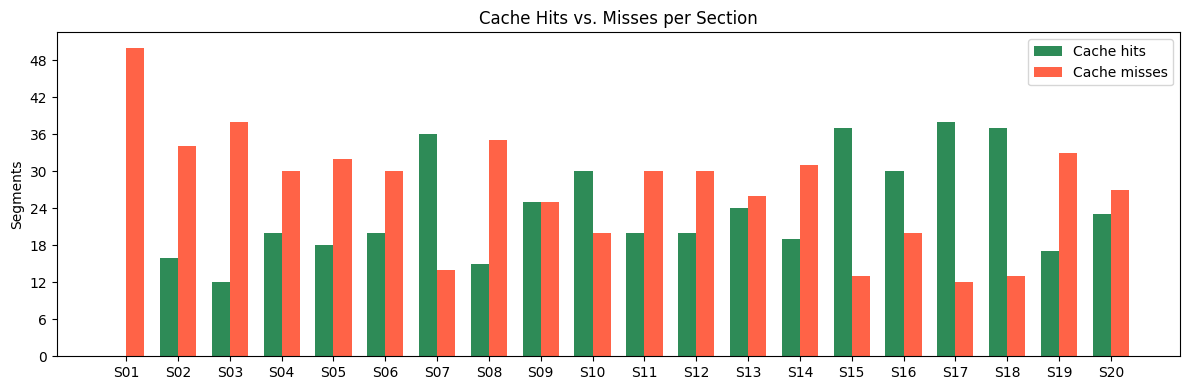

In [12]:
# Cell 12 — Cache hits/misses (grouped bar chart)
sec_labels = [r["section"] for r in section_results]
hits_arr   = [r["hits"] for r in section_results]
misses_arr = [r["misses"] for r in section_results]
x = np.arange(len(sec_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, hits_arr,   width, label="Cache hits",   color="seagreen")
ax.bar(x + width/2, misses_arr, width, label="Cache misses", color="tomato")
ax.set_title("Cache Hits vs. Misses per Section")
ax.set_xticks(x)
ax.set_xticklabels(sec_labels)
ax.set_ylabel("Segments")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

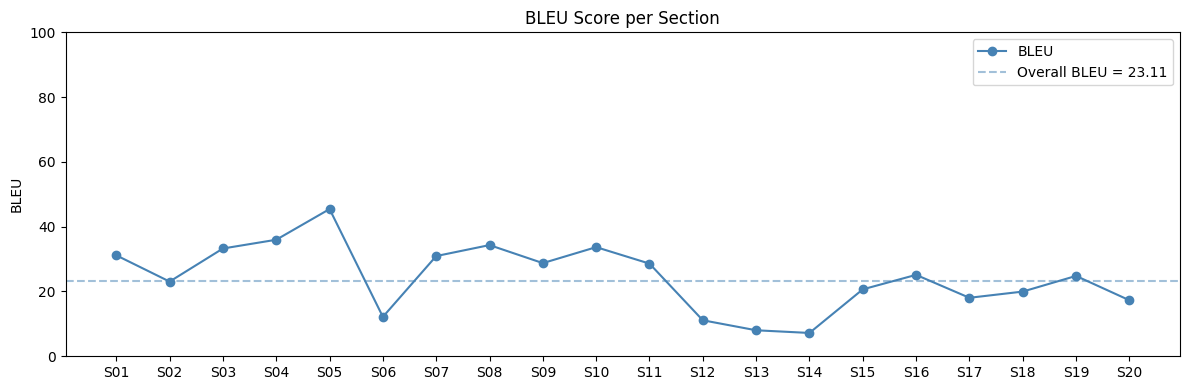

In [13]:
# Cell 13 — BLEU per section (line chart)
bleu_arr = [r["bleu"] for r in section_results]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sec_labels, bleu_arr, marker="o", color="steelblue", label="BLEU")
ax.axhline(overall_bleu, linestyle="--", color="steelblue", alpha=0.5,
           label=f"Overall BLEU = {overall_bleu:.2f}")
ax.set_title("BLEU Score per Section")
ax.set_ylabel("BLEU")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

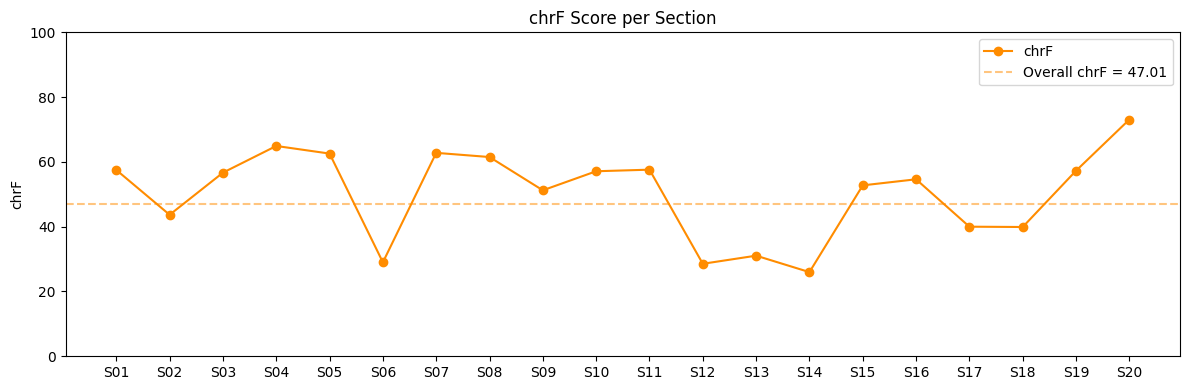

In [14]:
# Cell 14 — chrF per section (line chart)
chrf_arr = [r["chrf"] for r in section_results]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sec_labels, chrf_arr, marker="o", color="darkorange", label="chrF")
ax.axhline(overall_chrf, linestyle="--", color="darkorange", alpha=0.5,
           label=f"Overall chrF = {overall_chrf:.2f}")
ax.set_title("chrF Score per Section")
ax.set_ylabel("chrF")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

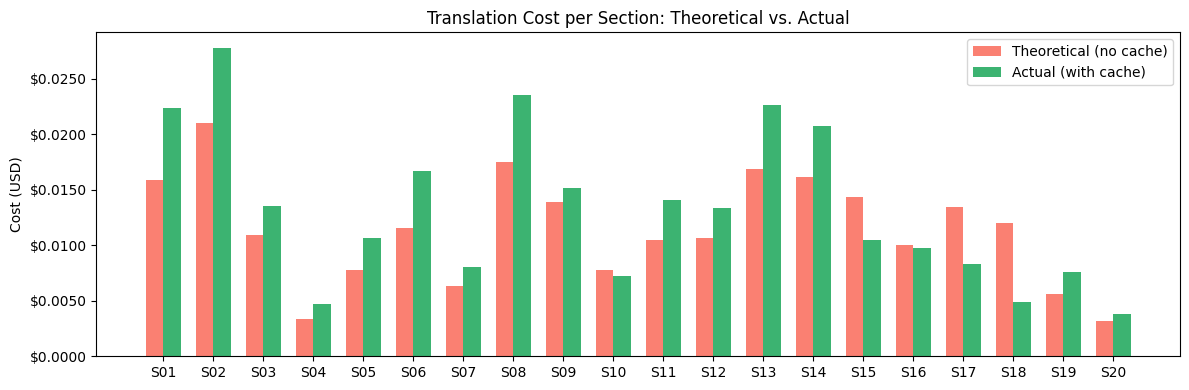

In [15]:
# Cell 15 — Cost comparison: theoretical (no-cache) vs. actual (with cache)
theor_arr  = [r["theoretical_cost"] for r in section_results]
actual_arr = [r["actual_cost"] for r in section_results]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, theor_arr,  width, label="Theoretical (no cache)", color="salmon")
ax.bar(x + width/2, actual_arr, width, label="Actual (with cache)",    color="mediumseagreen")
ax.set_title("Translation Cost per Section: Theoretical vs. Actual")
ax.set_xticks(x)
ax.set_xticklabels(sec_labels)
ax.set_ylabel("Cost (USD)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.4f"))
ax.legend()
plt.tight_layout()
plt.show()

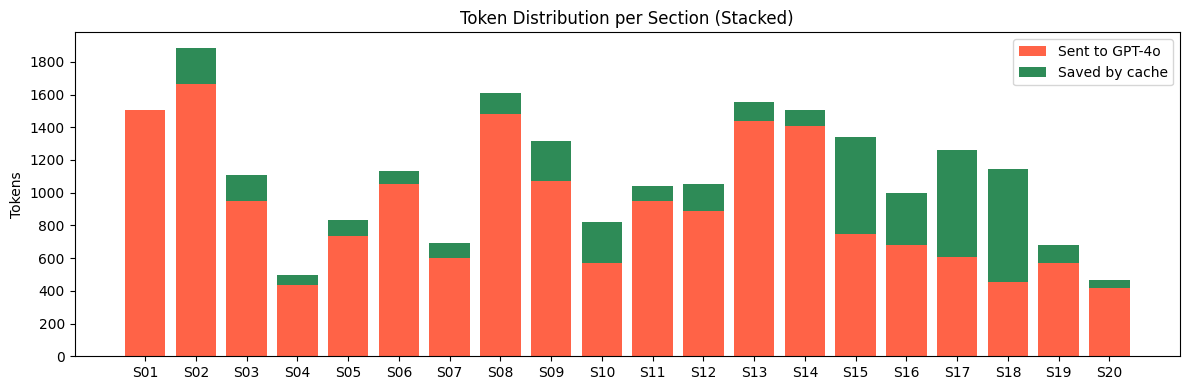

In [16]:
# Cell 16 — Token distribution: sent to GPT-4o vs. saved by cache (stacked bar)
gpt_tokens_arr   = [r["actual_input_tok"] for r in section_results]
saved_tokens_arr = [r["saved_tokens"] for r in section_results]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sec_labels, gpt_tokens_arr,   label="Sent to GPT-4o",  color="tomato")
ax.bar(sec_labels, saved_tokens_arr, bottom=gpt_tokens_arr,
       label="Saved by cache", color="seagreen")
ax.set_title("Token Distribution per Section (Stacked)")
ax.set_ylabel("Tokens")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

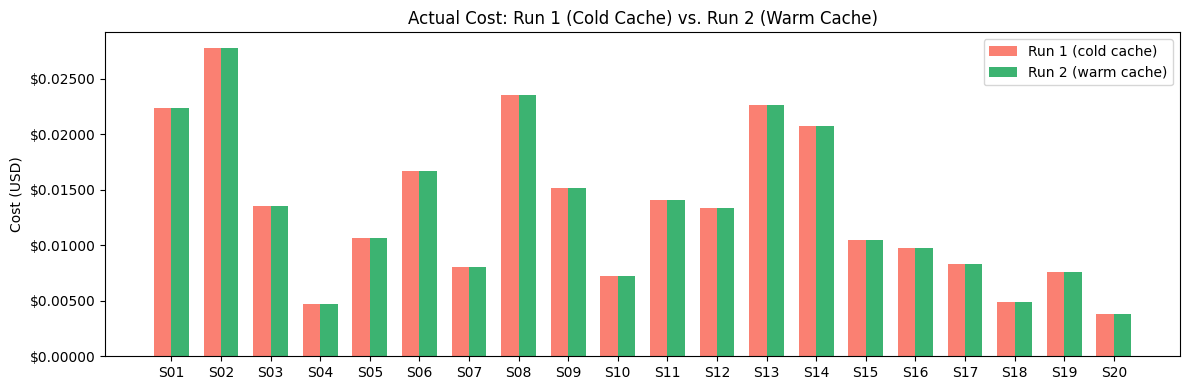

Run 1 total cost: $0.26527
Run 2 total cost: $0.26527
Cache savings:    0.0%


In [17]:
# Cell 17 — Run 1 vs. Run 2 cost comparison
# Only meaningful after re-running Cells 8-9 for Run 2 (section_results will contain Run 2 data)
# run1_results must have been saved in Cell 10 before the second run.

if len(run1_results) == len(section_results) and run1_results is not section_results:
    run1_cost = [r["actual_cost"] for r in run1_results]
    run2_cost = [r["actual_cost"] for r in section_results]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - width/2, run1_cost, width, label="Run 1 (cold cache)", color="salmon")
    ax.bar(x + width/2, run2_cost, width, label="Run 2 (warm cache)", color="mediumseagreen")
    ax.set_title("Actual Cost: Run 1 (Cold Cache) vs. Run 2 (Warm Cache)")
    ax.set_xticks(x)
    ax.set_xticklabels(sec_labels)
    ax.set_ylabel("Cost (USD)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.5f"))
    ax.legend()
    plt.tight_layout()
    plt.show()

    total_r1 = sum(run1_cost)
    total_r2 = sum(run2_cost)
    savings_pct = (1 - total_r2 / total_r1) * 100 if total_r1 > 0 else 0
    print(f"Run 1 total cost: ${total_r1:.5f}")
    print(f"Run 2 total cost: ${total_r2:.5f}")
    print(f"Cache savings:    {savings_pct:.1f}%")
else:
    print("Re-run Cells 8–9 (without restarting the kernel) to populate Run 2 data, "
          "then run this cell again.")

## Notes & Interpretation

- **Run 2 cost ≈ $0** because all 200 segments are already stored in the `EphemeralClient` — every query returns a cosine distance < 0.3.
- **BLEU scores vary** by section. Sections dominated by tables (country names, numbers, dates) tend to score higher because those tokens don't require morphological transformation.
- **chrF is more robust than BLEU** for morphologically rich languages like Czech: it matches character n-grams, so inflectional variation hurts it less.
- **Cache threshold:** cosine distance < 0.3 (same as production). Segments that differ even slightly in wording will miss the cache on Run 1.
- **Theoretical cost** assumes tiktoken count as both input and output tokens (1:1 ratio). Actual costs differ because GPT-4o adds prompt overhead (system message, JSON schema) to the input count.